<a href="https://colab.research.google.com/github/OJB-Quantum/QC-Hardware-How-To/blob/main/Jupyter%20Notebook%20Scripts/I_V_Characteristics_of_Superconductors_and_JJs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

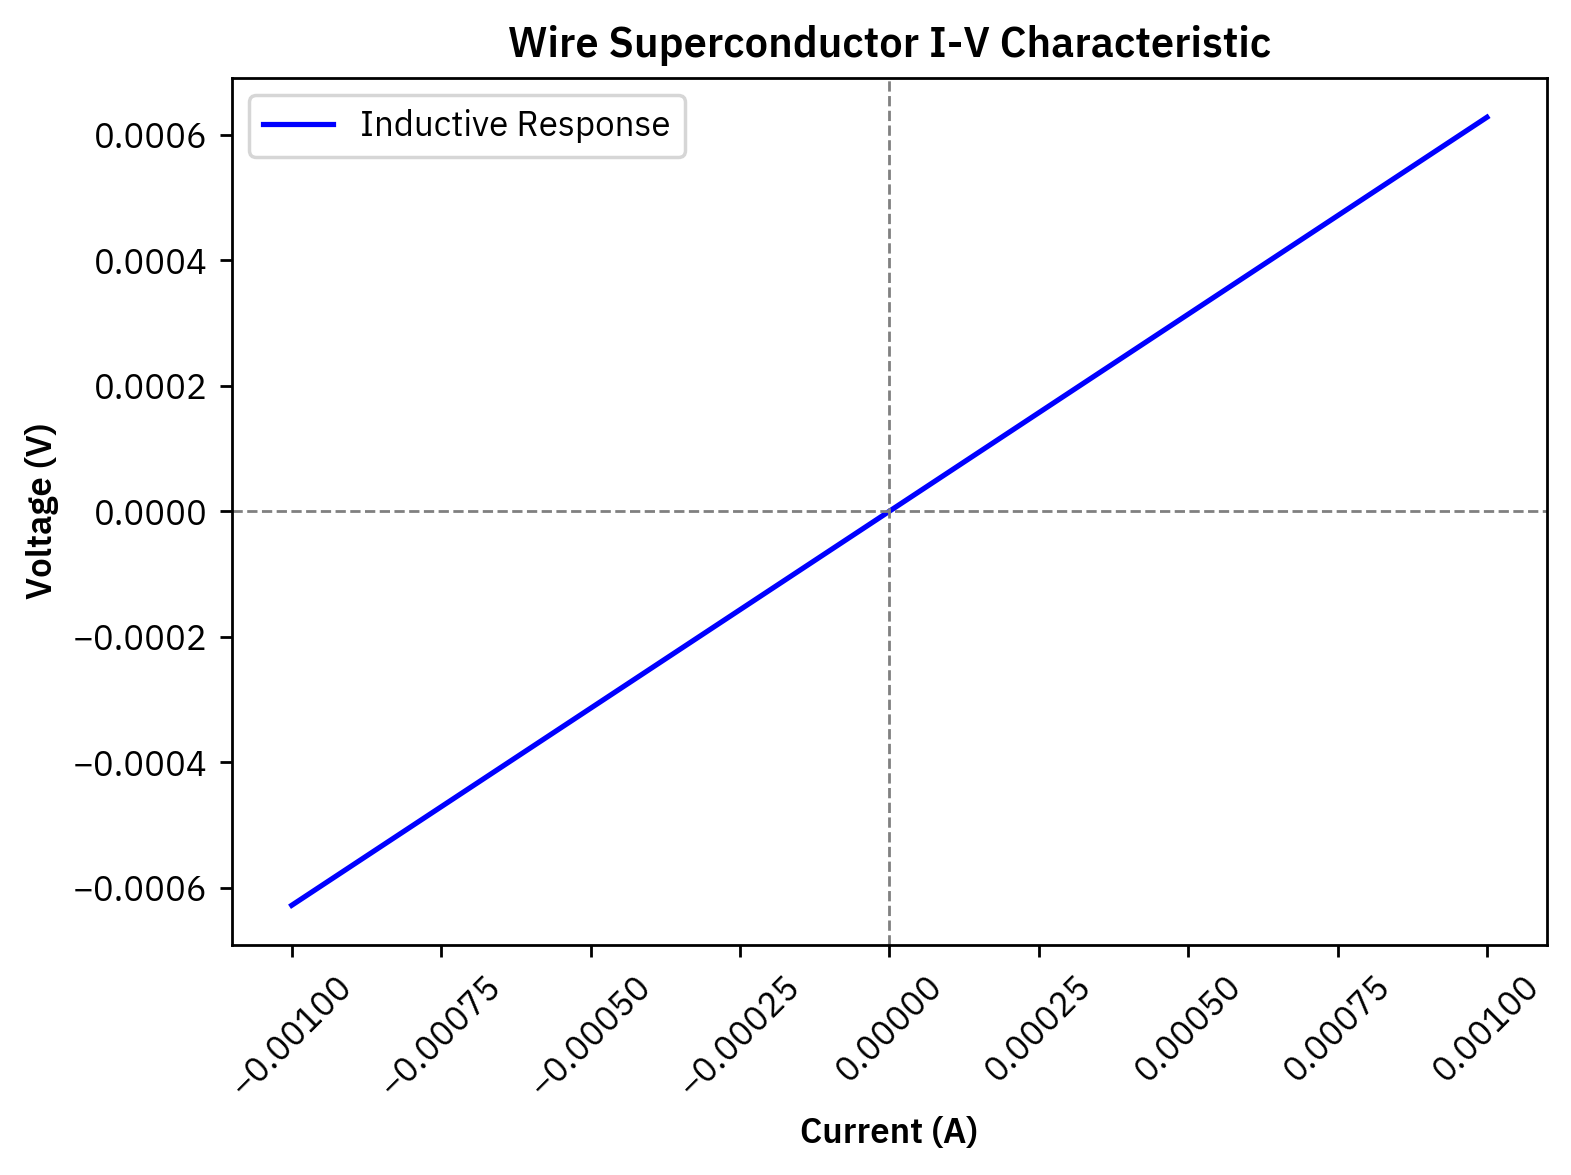

In [7]:
"""Simulate and plot the current voltage characteristic of a superconducting wire.

This module evaluates a continuous superconducting wire operating below its
critical current, where the physical behavior is primarily inductive and
effectively linear.
"""

import os
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# Control Parameters for straightforward adjustment
INDUCTANCE_H = 10e-9
FREQUENCY_HZ = 10e6
MIN_CURRENT_A = -1e-3
MAX_CURRENT_A = 1e-3
NUM_POINTS = 200


def configure_custom_typography() -> None:
    """Download and register the IBM Plex Sans TrueType Font (TTF) binaries."""
    base_url = "https://raw.githubusercontent.com/IBM/plex/master/packages/plex-sans/fonts/complete/ttf/"
    fonts_to_register = [
        "IBMPlexSans-Regular.ttf",
        "IBMPlexSans-SemiBold.ttf"
    ]

    for font_file in fonts_to_register:
        if not os.path.exists(font_file):
            urllib.request.urlretrieve(base_url + font_file, font_file)

        # Register the downloaded font directly with Matplotlib
        fm.fontManager.addfont(font_file)


def plot_superconductor_iv_characteristic(
    inductance: float,
    frequency: float,
    min_current: float,
    max_current: float,
    num_points: int,
) -> None:
    """Plot the inductive current voltage response of a continuous superconductor.

    Parameters
    ----------
    inductance : float
        The inductance of the superconducting wire in henries (H).
    frequency : float
        The operating frequency in hertz (Hz).
    min_current : float
        The minimum current value for the simulation range in amperes (A).
    max_current : float
        The maximum current value for the simulation range in amperes (A).
    num_points : int
        The number of discrete data points to generate for the plot.
    """
    # Initialize the custom fonts before updating parameters
    configure_custom_typography()

    # Configure matplotlib parameters for high resolution Colab rendering
    # incorporating fallback fonts to ensure silent degradation
    plt.rcParams.update({
        'figure.dpi': 250,
        'font.family': 'sans-serif',
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
    })

    # Calculate angular frequency
    omega = 2 * np.pi * frequency

    # Generate current range array
    current_array = np.linspace(min_current, max_current, num_points)

    # Calculate corresponding voltage based on linear inductance (V = \omega L I)
    voltage_array = omega * inductance * current_array

    # Initialize plot canvas
    fig, ax = plt.subplots()

    # Plot the inductive response curve using a pure blue hexadecimal color
    ax.plot(
        current_array,
        voltage_array,
        color='#0000FF',
        label='Inductive Response'
    )

    # Add zero reference markers
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    # Configure precise axis labels and scientific title
    ax.set_xlabel('Current (A)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title('Wire Superconductor I-V Characteristic')

    # Display plot legend
    ax.legend()

    # Optimize layout and graphical tick orientations
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Render plot directly in the current environment
    plt.show()


if __name__ == '__main__':
    plot_superconductor_iv_characteristic(
        inductance=INDUCTANCE_H,
        frequency=FREQUENCY_HZ,
        min_current=MIN_CURRENT_A,
        max_current=MAX_CURRENT_A,
        num_points=NUM_POINTS,
    )

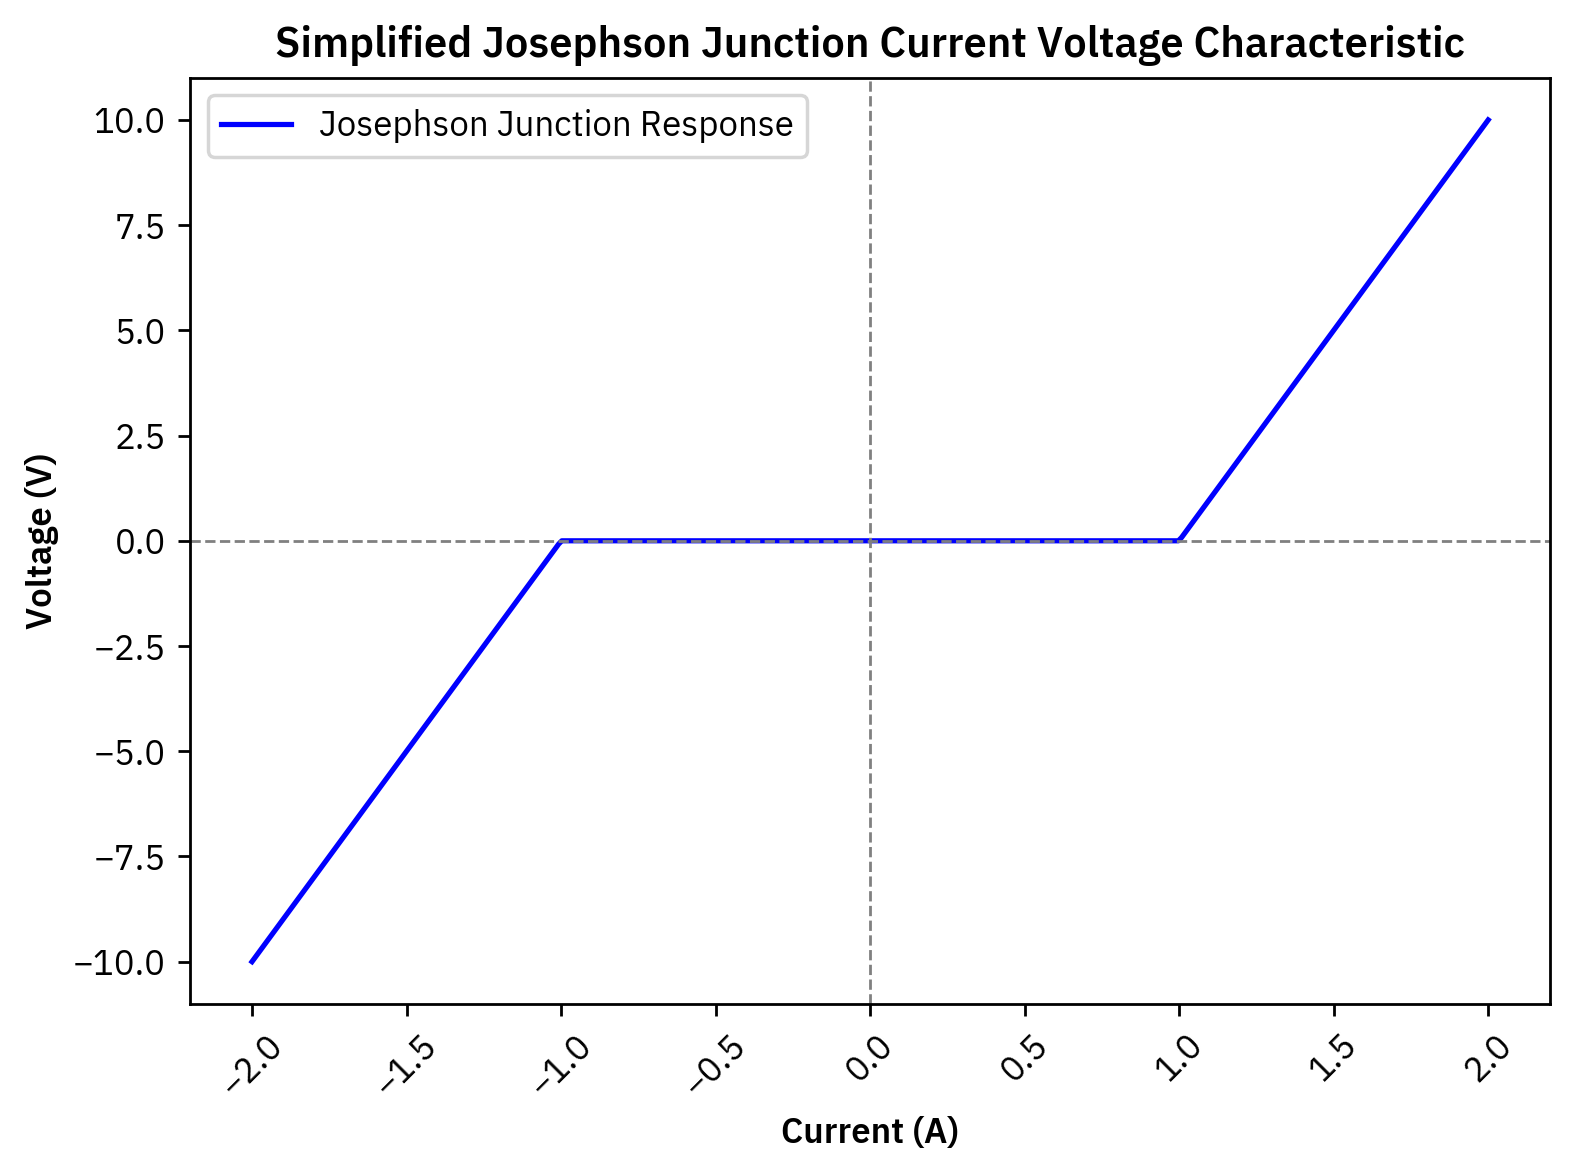

In [8]:
"""Simulate and plot the piecewise current voltage characteristic of a Josephson junction.

This module evaluates a simplified phenomenological model of a Josephson junction,
capturing the purely non dissipative supercurrent regime alongside the finite voltage
resistive branches that emerge upon exceeding the characteristic critical current.
"""

import os
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# Control Parameters for straightforward adjustment
CRITICAL_CURRENT_A = 1.0
NORMAL_RESISTANCE_OHMS = 10.0
MIN_CURRENT_A = -2.0
MAX_CURRENT_A = 2.0
NUM_POINTS = 400


def configure_custom_typography() -> None:
    """Download and register the IBM Plex Sans TrueType Font (TTF) binaries."""
    base_url = "https://raw.githubusercontent.com/IBM/plex/master/packages/plex-sans/fonts/complete/ttf/"
    fonts_to_register = [
        "IBMPlexSans-Regular.ttf",
        "IBMPlexSans-SemiBold.ttf"
    ]

    for font_file in fonts_to_register:
        if not os.path.exists(font_file):
            urllib.request.urlretrieve(base_url + font_file, font_file)

        # Register the downloaded font directly with Matplotlib
        fm.fontManager.addfont(font_file)


def calculate_josephson_voltage(
    current_array: np.ndarray,
    critical_current: float,
    normal_resistance: float,
) -> np.ndarray:
    """Compute the voltage across a simplified phenomenological Josephson junction.

    Parameters
    ----------
    current_array : np.ndarray
        The array of applied electrical currents in amperes (A).
    critical_current : float
        The characteristic critical current threshold in amperes (A).
    normal_resistance : float
        The normal state shunt resistance in ohms.

    Returns
    -------
    np.ndarray
        The resulting calculated piecewise voltage array in volts (V).
    """
    voltage_array = np.zeros_like(current_array)

    # Identify the non dissipative supercurrent region
    supercurrent_indices = np.where(np.abs(current_array) <= critical_current)[0]

    # Identify the positive ohmic dissipative region
    positive_ohmic_indices = np.where(current_array > critical_current)[0]

    # Identify the negative ohmic dissipative region
    negative_ohmic_indices = np.where(current_array < -critical_current)[0]

    # Assign corresponding piecewise voltages using vectorized operations
    voltage_array[supercurrent_indices] = 0.0
    voltage_array[positive_ohmic_indices] = (
        current_array[positive_ohmic_indices] - critical_current
    ) * normal_resistance

    voltage_array[negative_ohmic_indices] = (
        current_array[negative_ohmic_indices] + critical_current
    ) * normal_resistance

    return voltage_array


def plot_josephson_iv_characteristic(
    critical_current: float,
    normal_resistance: float,
    min_current: float,
    max_current: float,
    num_points: int,
) -> None:
    """Plot the pure blue current voltage response of a Josephson junction.

    Parameters
    ----------
    critical_current : float
        The characteristic critical current threshold in amperes (A).
    normal_resistance : float
        The normal state shunt resistance in ohms.
    min_current : float
        The minimum current boundary for the simulation domain in amperes (A).
    max_current : float
        The maximum current boundary for the simulation domain in amperes (A).
    num_points : int
        The total number of discrete data points populating the arrays.
    """
    # Initialize the custom fonts before updating plotting parameters
    configure_custom_typography()

    # Configure matplotlib parameters for high resolution Colab rendering
    # incorporating fallback fonts to ensure silent degradation
    plt.rcParams.update({
        'figure.dpi': 250,
        'font.family': 'sans-serif',
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
    })

    # Generate current domain array
    current_array = np.linspace(min_current, max_current, num_points)

    # Compute the piecewise voltage mapping
    voltage_array = calculate_josephson_voltage(
        current_array,
        critical_current,
        normal_resistance
    )

    # Initialize the plot canvas
    fig, ax = plt.subplots()

    # Plot the piecewise response curve using a pure blue hexadecimal color
    ax.plot(
        current_array,
        voltage_array,
        color='#0000FF',
        label='Josephson Junction Response'
    )

    # Add reference markers for the origin axes
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    # Configure precise axis labels and scientific typography
    ax.set_xlabel('Current (A)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title('Simplified Josephson Junction Current Voltage Characteristic')

    # Display the descriptive plot legend
    ax.legend()

    # Optimize spatial layout and graphical tick orientations
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Render plot directly into the current interactive environment
    plt.show()


if __name__ == '__main__':
    plot_josephson_iv_characteristic(
        critical_current=CRITICAL_CURRENT_A,
        normal_resistance=NORMAL_RESISTANCE_OHMS,
        min_current=MIN_CURRENT_A,
        max_current=MAX_CURRENT_A,
        num_points=NUM_POINTS,
    )

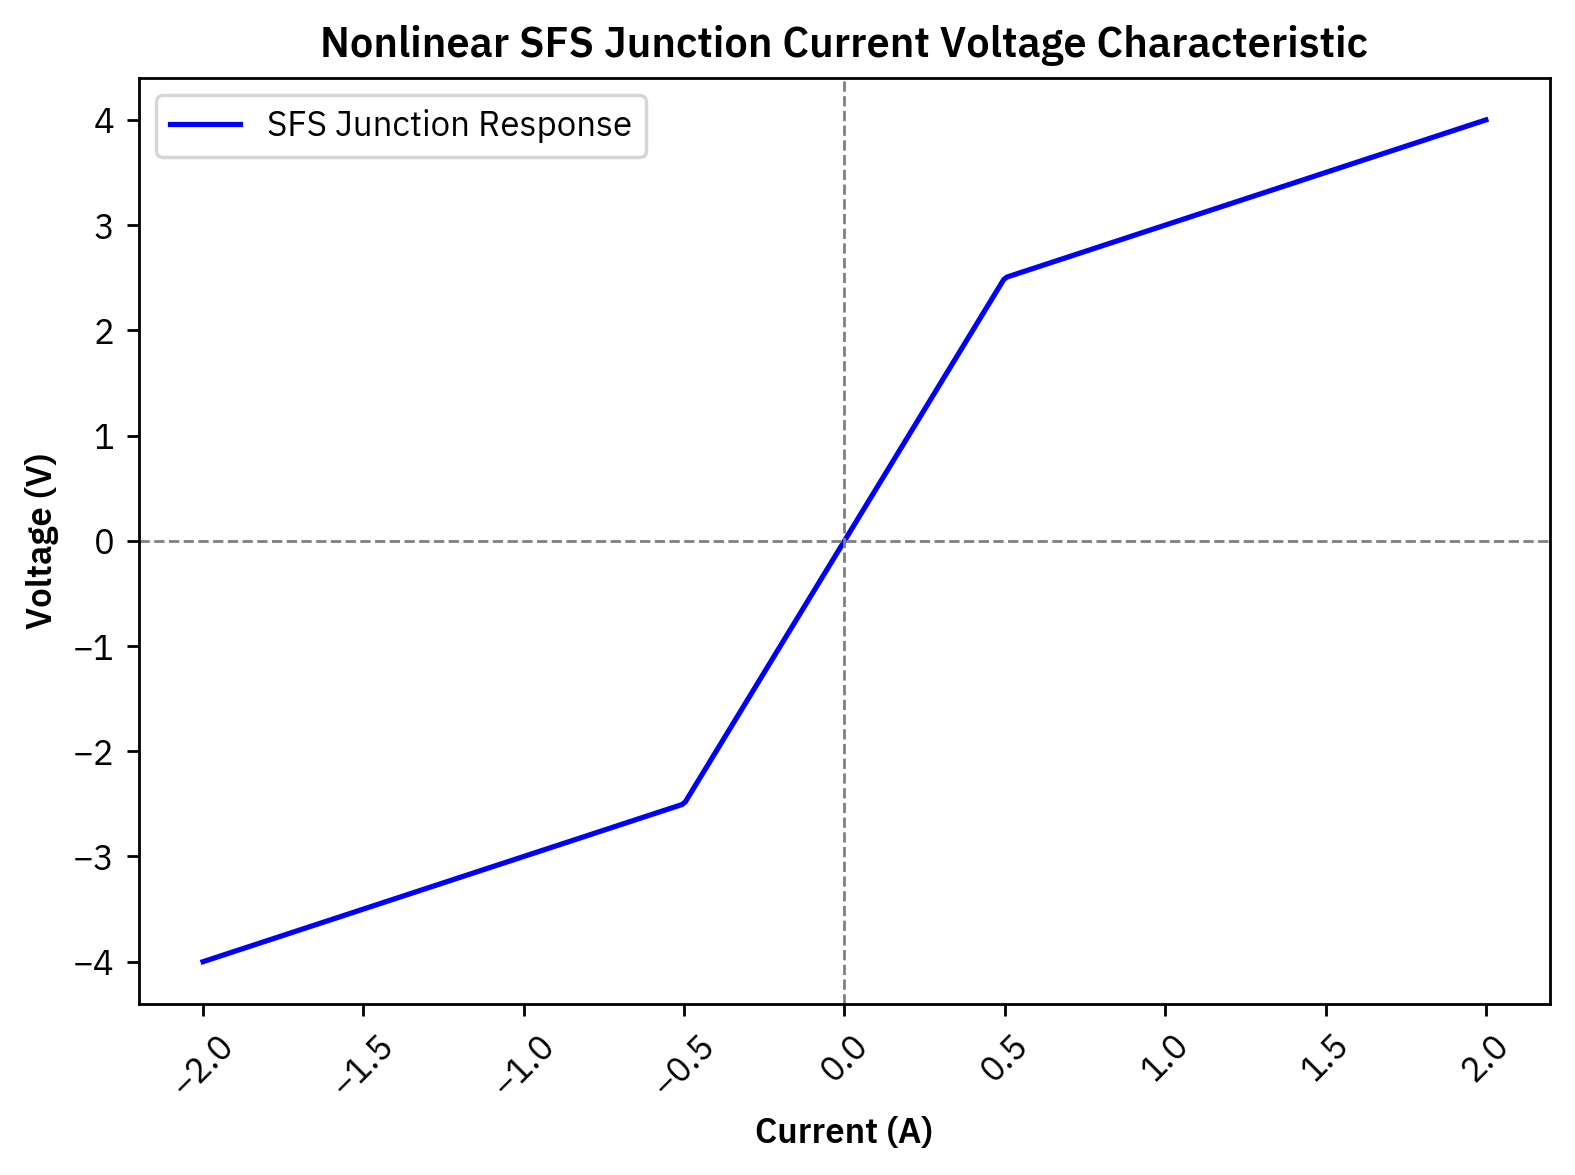

In [9]:
"""Simulate and plot the nonlinear current voltage characteristic of an SFS junction.

This module evaluates a piecewise phenomenological model of a Superconductor
Ferromagnet Superconductor junction, which captures both the finite subgap
leakage conduction and the normal state resistive transition.
"""

import os
import urllib.request
import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
import numpy as np

# Control Parameters for straightforward adjustment
CRITICAL_CURRENT_A = 0.5
SUBGAP_RESISTANCE_OHMS = 5.0
NORMAL_RESISTANCE_OHMS = 1.0
MIN_CURRENT_A = -2.0
MAX_CURRENT_A = 2.0
NUM_POINTS = 400


def configure_custom_typography() -> None:
    """Download and register the IBM Plex Sans TrueType Font (TTF) binaries."""
    base_url = "https://raw.githubusercontent.com/IBM/plex/master/packages/plex-sans/fonts/complete/ttf/"
    fonts_to_register = [
        "IBMPlexSans-Regular.ttf",
        "IBMPlexSans-SemiBold.ttf"
    ]

    for font_file in fonts_to_register:
        if not os.path.exists(font_file):
            urllib.request.urlretrieve(base_url + font_file, font_file)

        # Register the downloaded font directly with Matplotlib
        fm.fontManager.addfont(font_file)


def calculate_sfs_junction_voltage(
    current_array: np.ndarray,
    critical_current: float,
    subgap_resistance: float,
    normal_resistance: float,
) -> np.ndarray:
    """Compute the piecewise voltage across a phenomenological SFS junction.

    Parameters
    ----------
    current_array : np.ndarray
        The array of applied electrical currents in amperes (A).
    critical_current : float
        The critical current threshold separating the conduction regimes (A).
    subgap_resistance : float
        The effective resistance governing the subgap leakage region (ohms).
    normal_resistance : float
        The characteristic resistance governing the normal state region (ohms).

    Returns
    -------
    np.ndarray
        The computed piecewise voltage array in volts (V).
    """
    voltage_array = np.zeros_like(current_array)

    # Isolate the internal subgap leakage regime
    subgap_indices = np.where(np.abs(current_array) <= critical_current)[0]

    # Isolate the external normal state conduction regime
    normal_indices = np.where(np.abs(current_array) > critical_current)[0]

    # Calculate the linear voltage response for the subgap domain
    voltage_array[subgap_indices] = subgap_resistance * current_array[subgap_indices]

    # Retrieve the normal state current subset for continuous piecewise matching
    normal_currents = current_array[normal_indices]
    current_signs = np.sign(normal_currents)

    # Calculate the continuous voltage response for the normal domain
    voltage_array[normal_indices] = (
        subgap_resistance * critical_current * current_signs +
        normal_resistance * (np.abs(normal_currents) - critical_current) * current_signs
    )

    return voltage_array


def plot_sfs_iv_characteristic(
    critical_current: float,
    subgap_resistance: float,
    normal_resistance: float,
    min_current: float,
    max_current: float,
    num_points: int,
) -> None:
    """Plot the pure blue current voltage response of an SFS junction.

    Parameters
    ----------
    critical_current : float
        The critical current threshold separating the conduction regimes (A).
    subgap_resistance : float
        The effective resistance governing the subgap leakage region (ohms).
    normal_resistance : float
        The characteristic resistance governing the normal state region (ohms).
    min_current : float
        The minimum current boundary for the simulation domain in amperes (A).
    max_current : float
        The maximum current boundary for the simulation domain in amperes (A).
    num_points : int
        The total number of discrete data points populating the arrays.
    """
    # Initialize the custom typography before modifying system parameters
    configure_custom_typography()

    # Configure matplotlib parameters for high resolution Colab rendering
    # incorporating systematic fallback fonts to ensure silent degradation
    plt.rcParams.update({
        'figure.dpi': 250,
        'font.family': 'sans-serif',
        'font.sans-serif': ['IBM Plex Sans', 'DejaVu Sans', 'Arial', 'sans-serif'],
        'axes.titlesize': 12,
        'axes.labelsize': 10,
        'font.weight': 'normal',
        'axes.titleweight': 'semibold',
    })

    # Generate the linear current domain array
    current_array = np.linspace(min_current, max_current, num_points)

    # Compute the piecewise nonlinear voltage mapping
    voltage_array = calculate_sfs_junction_voltage(
        current_array,
        critical_current,
        subgap_resistance,
        normal_resistance,
    )

    # Initialize the plotting canvas
    fig, ax = plt.subplots()

    # Plot the piecewise response curve using a pure blue hexadecimal color
    ax.plot(
        current_array,
        voltage_array,
        color='#0000FF',
        label='SFS Junction Response'
    )

    # Add background reference markers for the origin axes
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')

    # Configure precise axis labels alongside scientific typography
    ax.set_xlabel('Current (A)')
    ax.set_ylabel('Voltage (V)')
    ax.set_title('Nonlinear SFS Junction Current Voltage Characteristic')

    # Display the explicitly configured plot legend
    ax.legend()

    # Optimize the spatial layout alongside graphical tick orientations
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Render the plot directly into the current interactive environment
    plt.show()


if __name__ == '__main__':
    plot_sfs_iv_characteristic(
        critical_current=CRITICAL_CURRENT_A,
        subgap_resistance=SUBGAP_RESISTANCE_OHMS,
        normal_resistance=NORMAL_RESISTANCE_OHMS,
        min_current=MIN_CURRENT_A,
        max_current=MAX_CURRENT_A,
        num_points=NUM_POINTS,
    )